In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import mat73
import pickle
import pandas as pd
import pingouin as pg
import xarray as xr
from globals import behavDir
from util import hedges_g

import pandas as pd
from lfp import make_freq_masks
import globals as gl

import seaborn as sb
import PcmPy as pcm
from scipy.stats import norm
plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


In [2]:
### colours ###
cmap_plan = plt.get_cmap('Greys')
col_plan = [cmap_plan(i) for i in np.linspace(.3, .9, 5)]

cmap_index = plt.get_cmap('Greens')
col_index = [cmap_index(i) for i in np.linspace(.3, .9, 5)][:4]

cmap_ring = plt.get_cmap('Oranges')
col_ring = [cmap_ring(i) for i in np.linspace(.3, .9, 5)][1:]

colour_mapping = {
    '100-0%': col_plan[0],
    '75-25%': col_plan[1],
    '50-50%': col_plan[2],
    '25-75%': col_plan[3],
    '0-100%': col_plan[4],
    '100-0%,ext': col_index[0],
    '75-25%,ext': col_index[1],
    '50-50%,ext': col_index[2],
    '25-75%,ext': col_index[3],
    '75-25%,flx': col_ring[0],
    '50-50%,flx': col_ring[1],
    '25-75%,flx': col_ring[2],
    '0-100%,flx': col_ring[3],
}

###############

In [3]:
baseDir = '/cifs/pruszynski/Marco/SensoriMotorPrediction'
lfpDir = 'LFPs' #+ monkey + '/'
spkDir = 'spikes' #+ monkey + '/'
pcmDir = 'pcm'
behavDir = 'Behavioural'
recDir = 'Recordings'
cfg = mat73.loadmat(os.path.join(baseDir, lfpDir,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

freqs = ['delta', 'theta', 'alpha-beta', 'gamma']
recordings = {
            'Malfoy': {
                'PMd': [10, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24],
                'M1': [12, 13, 25, 27, 28],
                'S1': [ 5, 9, 11, 15, 16, 26, 27, 28]
            },
            'Pert': {
                'PMd': [4, 6, 7, 10, 20],
                'M1': [2, 3, 14, 20],
                'S1': [15]
            }
        }

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre) + 5
t = np.concatenate((t_cue, t_pert))

monkey = ['Malfoy', 'Pert']

rois = ['PMd', 'S1']
freq = freq_masks['alpha-beta']

var_expl = {"lfp": [], "spk": [], 'roi': []}  # each becomes list over rois
kin = {"elbow": [], "prob": [], 'cond': [], 'rec': [], 'roi': []}
corr = {"lfp": [], "spk": [], 'roi': []}
epoch = 'plan'
for roi in rois:
    for mon in monkey:
        for rec in recordings[mon][roi]:
            theta_lfp_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.lfp.component.{roi}.{epoch}-{rec}.npy'))
            theta_spk_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.spk.component.{roi}.{epoch}-{rec}.npy'))
            var_tot_lfp = np.load(os.path.join(baseDir, pcmDir, mon, f'var_tot.lfp.{roi}.{epoch}-{rec}.npy'))
            var_tot_spk = np.load(os.path.join(baseDir, pcmDir, mon, f'var_tot.spk.{roi}.{epoch}-{rec}.npy'))
            var_expl["lfp"].append(np.exp(theta_lfp_comp[...,:-1]) / var_tot_lfp.T[..., None])
            var_expl["spk"].append(np.exp(theta_spk_comp[:, :-1]) / var_tot_spk.T[..., None])
            var_expl["roi"].append(roi)

var_expl_lfp_plan = xr.DataArray(data=np.stack(var_expl["lfp"]),
                   dims=('roi', 'freq', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'freq': foi,
                       'time': t,
                       'model': ['cue', 'uncertainty']})
var_expl_spk_plan = xr.DataArray(data=np.stack(var_expl["spk"]),
                   dims=('roi', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'time': t,
                       'model': ['cue', 'uncertainty']})

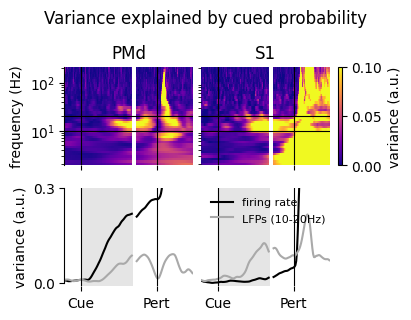

In [47]:
fig, axs_ = plt.subplots(2, 3, sharex='col', figsize=(4, 3), gridspec_kw={"width_ratios": [80, 80, 2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

vmin, vmax = 0, .1
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
label = ['cue', 'uncertainty']
for r, roi in enumerate(['PMd', 'S1']):
    lfp_tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model='cue').mean(dim='roi').values
    lfp_tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model='cue').mean(dim='roi').values
    lfp_t1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model='cue', freq=slice(10, 20)).mean(dim=('roi', 'freq')).values
    lfp_t2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model='cue', freq=slice(10, 20)).mean(dim=('roi', 'freq')).values
    h = axs[0, r].pcolormesh(t_cue, foi, lfp_tf1, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].pcolormesh(t_pert, foi, lfp_tf2, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(10, color='k', lw='.8')
    axs[0, r].axhline(20, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    firing1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, cuePost-1), model='cue').mean(dim='roi').values
    firing2 = var_expl_spk_plan.sel(roi=roi, time=slice(pertPre, None), model='cue').mean(dim='roi').values
    axs[1, r].plot(t_cue, firing1, color='k', label='firing rate')
    axs[1, r].plot(t_pert, firing2, color='k')
    axs[1, r].plot(t_cue, lfp_t1, color='darkgrey', label='LFPs (10-20Hz)')
    axs[1, r].plot(t_pert, lfp_t2, color='darkgrey')
    axs[1, r].axvspan(cueIdx, cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([-.01, .3])
    axs[1, r].set_yticks((0, .3))
    axs[1, r].spines['left'].set_bounds(0, .3)
    axs[1, r].set_ylabel('variance (a.u.)') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(cueIdx, color='k', lw='.8')
        axs[i, r].axvline(pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([cueIdx, pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[1, 1].legend(frameon=False, ncol=1, fontsize=8, loc='upper left')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'Variance explained by cued probability', va='center')

plt.show()

        Source        SS  DF1  DF2        MS          F     p-unc       np2  \
0          roi  0.019946    1   24  0.019946  11.089173  0.002799  0.316028   
1     modality  0.017187    1   24  0.017187  11.276800  0.002613  0.319666   
2  Interaction  0.046903    1   24  0.046903  30.773718  0.000010  0.561834   

   eps  
0  NaN  
1  1.0  
2  NaN  


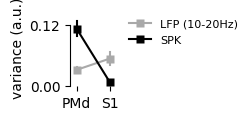

In [48]:
pmd_lfp = var_expl_lfp_plan.sel(roi='PMd', time=slice(cueIdx, cuePost), model='cue', freq=slice(10, 20)).mean(dim=('freq', 'time')).values
s1_lfp = var_expl_lfp_plan.sel(roi='S1', time=slice(cueIdx, cuePost), model='cue', freq=slice(10, 20)).mean(dim=('freq', 'time')).values
pmd_spk = var_expl_spk_plan.sel(roi='PMd', time=slice(cueIdx, cuePost), model='cue').mean(dim=('time')).values
s1_spk = var_expl_spk_plan.sel(roi='S1', time=slice(cueIdx, cuePost), model='cue').mean(dim=('time')).values

n_pmd = len(pmd_lfp)
n_s1 = len(s1_lfp)

df = pd.DataFrame({
    "var": np.concatenate([pmd_lfp, pmd_spk, s1_lfp, s1_spk]),
    "roi":   np.repeat(["PMd", "PMd", "S1", "S1"], [len(pmd_lfp), len(pmd_spk), len(s1_lfp), len(s1_spk)]),
    "modality": np.repeat(["LFP (10-20Hz)", "SPK", "LFP (10-20Hz)", "SPK"], [len(pmd_lfp), len(pmd_spk), len(s1_lfp), len(s1_spk)]),
    "subject": np.concatenate([
        np.arange(len(pmd_lfp)),                 # PMd subjects
        np.arange(len(pmd_spk)),                 # same PMd subjects
        np.arange(len(pmd_lfp), len(pmd_lfp)+len(s1_lfp)), # different S1 subjects
        np.arange(len(pmd_lfp), len(pmd_lfp)+len(s1_spk))  # same S1 subjects
    ])
})

aov = pg.mixed_anova(dv="var", within="modality", between="roi", subject="subject", data=df)

print(aov)

fig, ax = plt.subplots(figsize=(.6, 1))

sb.lineplot(data=df, y='var', x='roi', hue='modality', ax=ax, errorbar='se', marker='s', markeredgecolor='none', err_style='bars', palette=['darkgrey', 'k', ])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, frameon=False)
ax.set_xlim(-.2, 1.2)
ax.set_yticks([0, .12])
ax.set_ylim(0, .15)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_bounds(0, .12)
ax.set_xlabel(None)
ax.set_ylabel('variance (a.u.)')

plt.show()

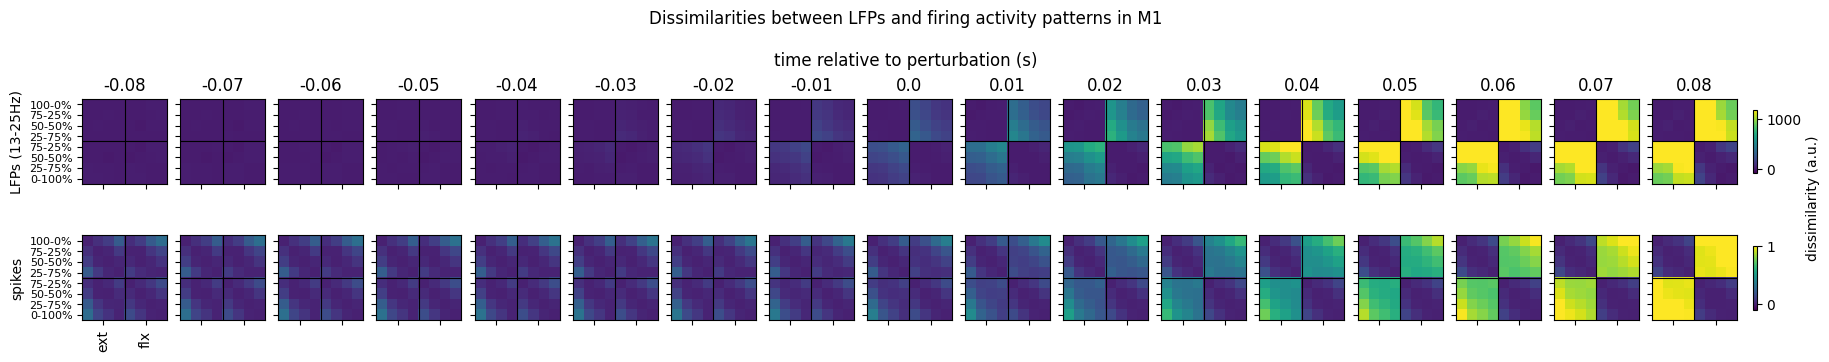

In [14]:
D_lfp, D_spk = [], []
for mon in monkey:
    for rec in recordings[mon]['M1']:
        G_lfp = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.lfp.M1.exec-{rec}.npy'))
        freq = freq_masks['beta']
        G_lfp = G_lfp[freq].mean(axis=0)
        G_spk = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.spk.M1.exec-{rec}.npy'))
        D_lfp.append(pcm.G_to_dist(G_lfp))
        D_spk.append(pcm.G_to_dist(G_spk))
D_lfp, D_spk = np.array(D_lfp).mean(axis=0), np.array(D_spk).mean(axis=0)
n_timep = 17
timep = np.linspace(-8, 8, n_timep, dtype=int)
fig, axs = plt.subplots(2, n_timep, figsize=(18, 3.5), sharex=True, sharey=True, constrained_layout=True)
for i in range(n_timep):
    ax = axs[:, i]
    ax[0].imshow(D_lfp[pertIdx+timep[i]], vmin=-100, vmax=1200)
    ax[1].imshow(D_spk[pertIdx+timep[i]], vmin=-.1, vmax=1)
    ax[0].set_title(timep[i] / 100)
    ax[0].set_yticks(np.arange(0, 8))
    ax[0].set_xticks(np.arange(1.5, 9.5, 4))
    ax[1].tick_params(labelbottom=False, labelleft=False)
    ax[0].tick_params(labelleft=False)
    for j in range(2):
        ax[j].axhline(3.5, color='k', lw='.8')
        ax[j].axvline(3.5, color='k', lw='.8')

axs[0, 0].set_ylabel('LFPs (13-25Hz)')
axs[1, 0].set_ylabel('spikes')
axs[0, 0].tick_params(labelleft=True)
axs[0, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_xticklabels(['ext', 'flx'], rotation=90)
axs[1, 0].tick_params(labelbottom=True, labelleft=True)
fig.suptitle('Dissimilarities between LFPs and firing activity patterns in M1\n\ntime relative to perturbation (s)')
cax = axs[0, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[0], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
cax = axs[1, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[1], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
fig.text(1, .45, 'dissimilarity (a.u.)', va='center', rotation='vertical', ha='left')

plt.show()

0
group estimate:-0.8449282287729698 central 90% CI for r: [-1.000, -0.628]
1
group estimate:0.43160774176752636 central 90% CI for r: [0.318, 0.520]


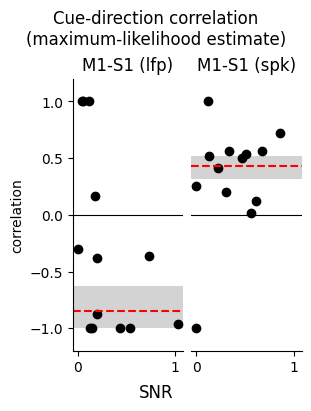

In [7]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)
dtype = ['lfp', 'spk']
fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))

for d, dt in enumerate(dtype):
    print(d)
    f = open(os.path.join(baseDir, pcmDir, f'theta_in.{dt}.corr_cue-dir.M1-S1.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(baseDir, pcmDir, f'r_bootstrap.{dt}.corr_cue-dir.M1-S1.npy'))
    f = open(os.path.join(baseDir, pcmDir, f'theta_gr.{dt}.corr_cue-dir.M1-S1.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, d, Mflex, theta, theta_g, r_bootstrap)
    axs[d].set_title(f'M1-S1 ({dt})')

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-direction correlation\n(maximum-likelihood estimate)')

plt.show()


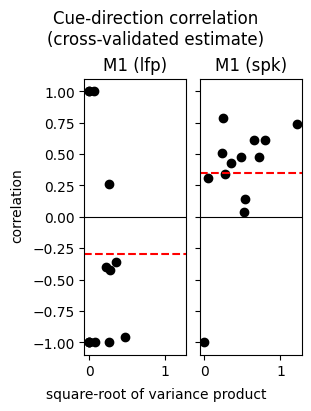

In [8]:
fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))
for d, dt in enumerate(dtype):
    ax = axs[d]
    G = np.load(os.path.join(baseDir, pcmDir, f'G_obs.{dt}.corr_cue-dir.M1-S1.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2) + 1e-6, -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(f'M1 ({dt})')

fig.suptitle('Cue-direction correlation\n(cross-validated estimate)')
fig.supxlabel('square-root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()